<a href="https://colab.research.google.com/github/MartinPapic/EcoViaje/blob/main/Ejercicio_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ejercicio 1, Preprocesamiento de datos 2026 / 1

Martín Papic, 12 de marzo del 2026

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
ruta = '/content/drive/MyDrive/quinto semestre/Preprocesamiento de datos/Clase 2/1.1.6. Archivo para actividad práctica.csv'

In [4]:
import pandas as pd

In [12]:
df = pd.read_csv(ruta)
df.head()

,S.NO,Name,Nationality,Current Rank,Previous Year Rank,Sport,Year,earnings ($ million)
0,1,Mike Tyson,USA,1,NaN,boxing,1990,28.6
1,2,Buster Douglas,USA,2,NaN,boxing,1990,26.0
2,3,Sugar Ray Leonard,USA,3,NaN,boxing,1990,13.0
3,4,Ayrton Senna,Brazil,4,NaN,auto racing,1990,10.0
4,5,Alain Prost,France,5,NaN,auto racing,1990,9.0


In [13]:
df.describe()

,S.NO,Current Rank,Year,earnings ($ million)
count,301.000000,301.000000,301.000000,301.000000
mean,151.000000,5.448505,2005.122924,45.516279
std,87.035433,2.850995,9.063563,33.525337
min,1.000000,1.000000,1990.000000,8.100000
25%,76.000000,3.000000,1997.000000,24.000000
50%,151.000000,5.000000,2005.000000,39.000000
75%,226.000000,8.000000,2013.000000,59.400000
max,301.000000,10.000000,2020.000000,300.000000


# Exploración estructural del dataset

En este notebook analizaremos la estructura de las variables del dataset.

Objetivos:

1. Identificar si cada variable es **estructurada o no estructurada**
2. Determinar su **naturaleza estadística**:
   - Numérica (discreta / continua)
   - Categórica (nominal / ordinal)
3. Determinar si existe **orden inherente**
4. Recomendar **estadísticos descriptivos apropiados**

El dataset contiene información sobre **deportistas mejor pagados por año**.

Variables presentes:

- S.NO
- Name
- Nationality
- Current Rank
- Previous Year Rank
- Sport
- Year
- earnings ($ million)

Usaremos `pandas`, `numpy`, `sklearn`, `matplotlib` y `seaborn` para realizar el análisis.

## Importar librerías

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

## Cargar dataset

In [15]:
# Si el dataset ya está cargado en df, omitir esto
# Ejemplo si se carga desde csv

# df = pd.read_csv("athletes_earnings.csv")

df.head()

,S.NO,Name,Nationality,Current Rank,Previous Year Rank,Sport,Year,earnings ($ million)
0,1,Mike Tyson,USA,1,NaN,boxing,1990,28.6
1,2,Buster Douglas,USA,2,NaN,boxing,1990,26.0
2,3,Sugar Ray Leonard,USA,3,NaN,boxing,1990,13.0
3,4,Ayrton Senna,Brazil,4,NaN,auto racing,1990,10.0
4,5,Alain Prost,France,5,NaN,auto racing,1990,9.0


## Inspección inicial del dataset

Analizamos:

- tipos de datos
- valores nulos
- cardinalidad de variables

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   S.NO                  301 non-null    int64  
 1   Name                  301 non-null    object 
 2   Nationality           301 non-null    object 
 3   Current Rank          301 non-null    int64  
 4   Previous Year Rank    277 non-null    object 
 5   Sport                 301 non-null    object 
 6   Year                  301 non-null    int64  
 7   earnings ($ million)  301 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 18.9+ KB


In [17]:
df.describe(include='all')

,S.NO,Name,Nationality,Current Rank,Previous Year Rank,Sport,Year,earnings ($ million)
count,301.000000,301,301,301.000000,277,301,301.000000,301.000000
unique,NaN,82,22,NaN,36,29,NaN,NaN
top,NaN,Michael Jordan,USA,NaN,>10,Basketball,NaN,NaN
freq,NaN,19,206,NaN,36,54,NaN,NaN
mean,151.000000,NaN,NaN,5.448505,NaN,NaN,2005.122924,45.516279
std,87.035433,NaN,NaN,2.850995,NaN,NaN,9.063563,33.525337
min,1.000000,NaN,NaN,1.000000,NaN,NaN,1990.000000,8.100000
25%,76.000000,NaN,NaN,3.000000,NaN,NaN,1997.000000,24.000000
50%,151.000000,NaN,NaN,5.000000,NaN,NaN,2005.000000,39.000000
75%,226.000000,NaN,NaN,8.000000,NaN,NaN,2013.000000,59.400000


In [18]:
df.isnull().sum()

,0
S.NO,0
Name,0
Nationality,0
Current Rank,0
Previous Year Rank,24
Sport,0
Year,0
earnings ($ million),0


## Clasificación conceptual de las variables

Clasificaremos cada variable según:

### 1. Tipo de estructura

- **Estructurada**: datos organizados en columnas con significado claro
- **No estructurada**: texto libre, imágenes, audio, etc.

En este dataset **todas las variables son estructuradas**, pero algunas son **texto categórico**.

### 2. Naturaleza estadística

| Variable | Tipo | Subtipo |
|---|---|---|
| S.NO | Numérica | Discreta |
| Name | Categórica | Nominal |
| Nationality | Categórica | Nominal |
| Current Rank | Numérica | Ordinal |
| Previous Year Rank | Numérica | Ordinal |
| Sport | Categórica | Nominal |
| Year | Numérica | Discreta |
| earnings ($ million) | Numérica | Continua |

### 3. Orden

| Variable | Orden |
|---|---|
| S.NO | Sí (índice) |
| Name | No |
| Nationality | No |
| Current Rank | Sí |
| Previous Year Rank | Sí |
| Sport | No |
| Year | Sí |
| earnings ($ million) | Sí |

## Generación automática de metadatos del dataset

In [19]:
metadata = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "missing_values": df.isnull().sum().values,
    "unique_values": [df[col].nunique() for col in df.columns]
})

metadata

,column,dtype,missing_values,unique_values
0,S.NO,int64,0,301
1,Name,object,0,82
2,Nationality,object,0,22
3,Current Rank,int64,0,10
4,Previous Year Rank,object,24,36
5,Sport,object,0,29
6,Year,int64,0,30
7,earnings ($ million),float64,0,198


## Clasificación automática de variables

Usaremos reglas simples:

- Si el tipo es `object` → categórica
- Si es numérica:
  - pocos valores → discreta
  - muchos valores → continua

In [20]:
def classify_variable(series):

    if series.dtype == 'object':
        return "Categorical (Nominal)"

    if pd.api.types.is_numeric_dtype(series):

        unique_ratio = series.nunique() / len(series)

        if unique_ratio < 0.05:
            return "Numeric Discrete"

        else:
            return "Numeric Continuous"

    return "Unknown"


metadata["statistical_type"] = df.apply(classify_variable).values

metadata

,column,dtype,missing_values,unique_values,statistical_type
0,S.NO,int64,0,301,Numeric Continuous
1,Name,object,0,82,Categorical (Nominal)
2,Nationality,object,0,22,Categorical (Nominal)
3,Current Rank,int64,0,10,Numeric Discrete
4,Previous Year Rank,object,24,36,Categorical (Nominal)
5,Sport,object,0,29,Categorical (Nominal)
6,Year,int64,0,30,Numeric Continuous
7,earnings ($ million),float64,0,198,Numeric Continuous


## Estadísticos descriptivos apropiados por tipo de variable

### Variables Numéricas

Se recomiendan:

- Media
- Mediana
- Desviación estándar
- Mínimo / Máximo
- Cuartiles

### Variables Categóricas

Se recomiendan:

- Frecuencia absoluta
- Frecuencia relativa
- Moda
- Número de categorías

In [21]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].describe()

,S.NO,Current Rank,Year,earnings ($ million)
count,301.000000,301.000000,301.000000,301.000000
mean,151.000000,5.448505,2005.122924,45.516279
std,87.035433,2.850995,9.063563,33.525337
min,1.000000,1.000000,1990.000000,8.100000
25%,76.000000,3.000000,1997.000000,24.000000
50%,151.000000,5.000000,2005.000000,39.000000
75%,226.000000,8.000000,2013.000000,59.400000
max,301.000000,10.000000,2020.000000,300.000000


## Visualización de distribuciones

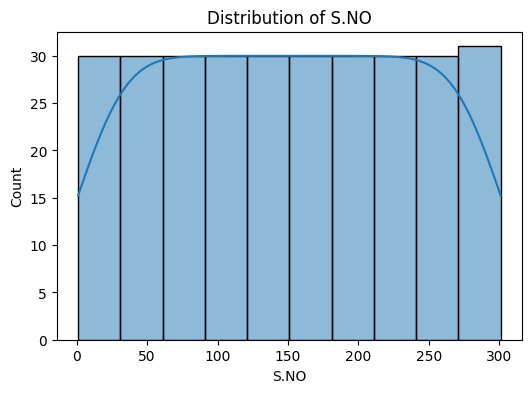

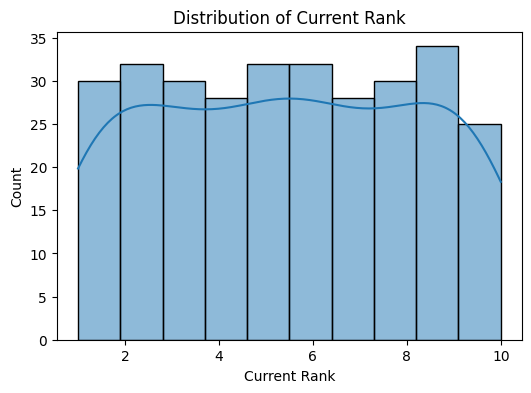

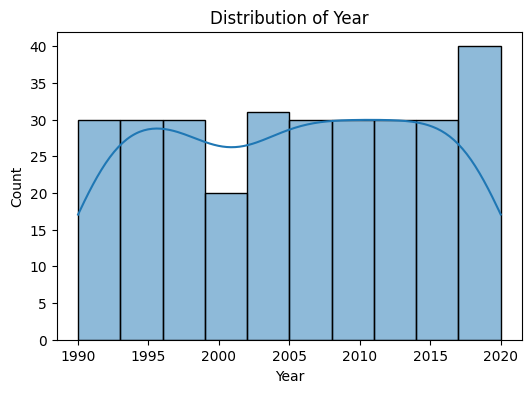

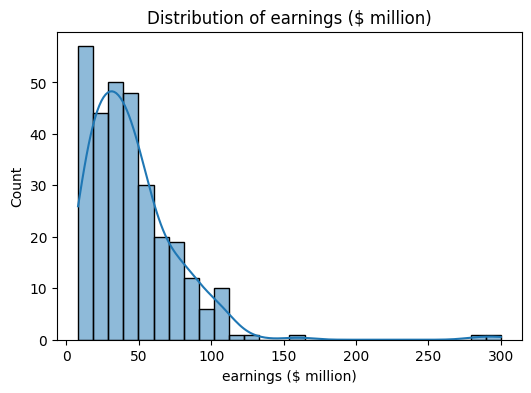

In [22]:
for col in numeric_cols:

    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## Estadísticos para variables categóricas

In [23]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:

    print("\n")
    print("Column:", col)

    print("Mode:")
    print(df[col].mode())

    print("\nValue Counts:")
    print(df[col].value_counts().head(10))



Column: Name
Mode:
0    Michael Jordan
1       Tiger Woods
Name: Name, dtype: object

Value Counts:
Name
Michael Jordan        19
Tiger Woods           19
Kobe Bryant           14
Michael Schumacher    13
LeBron James          13
Roger Federer         12
Phil Mickelson        11
Cristiano Ronaldo     10
Shaquille O'Neal       9
Lionel Messi           9
Name: count, dtype: int64


Column: Nationality
Mode:
0    USA
Name: Nationality, dtype: object

Value Counts:
Nationality
USA            206
UK              13
Germany         13
Switzerland     12
Portugal        10
Brazil           9
Argentina        9
Canada           6
Italy            4
France           3
Name: count, dtype: int64


Column: Previous Year Rank
Mode:
0    >10
Name: Previous Year Rank, dtype: object

Value Counts:
Previous Year Rank
>10    36
1      25
5      21
3      21
2      20
6      18
4      17
7      17
8      14
9      13
Name: count, dtype: int64


Column: Sport
Mode:
0    Basketball
Name: Sport, dtype: ob

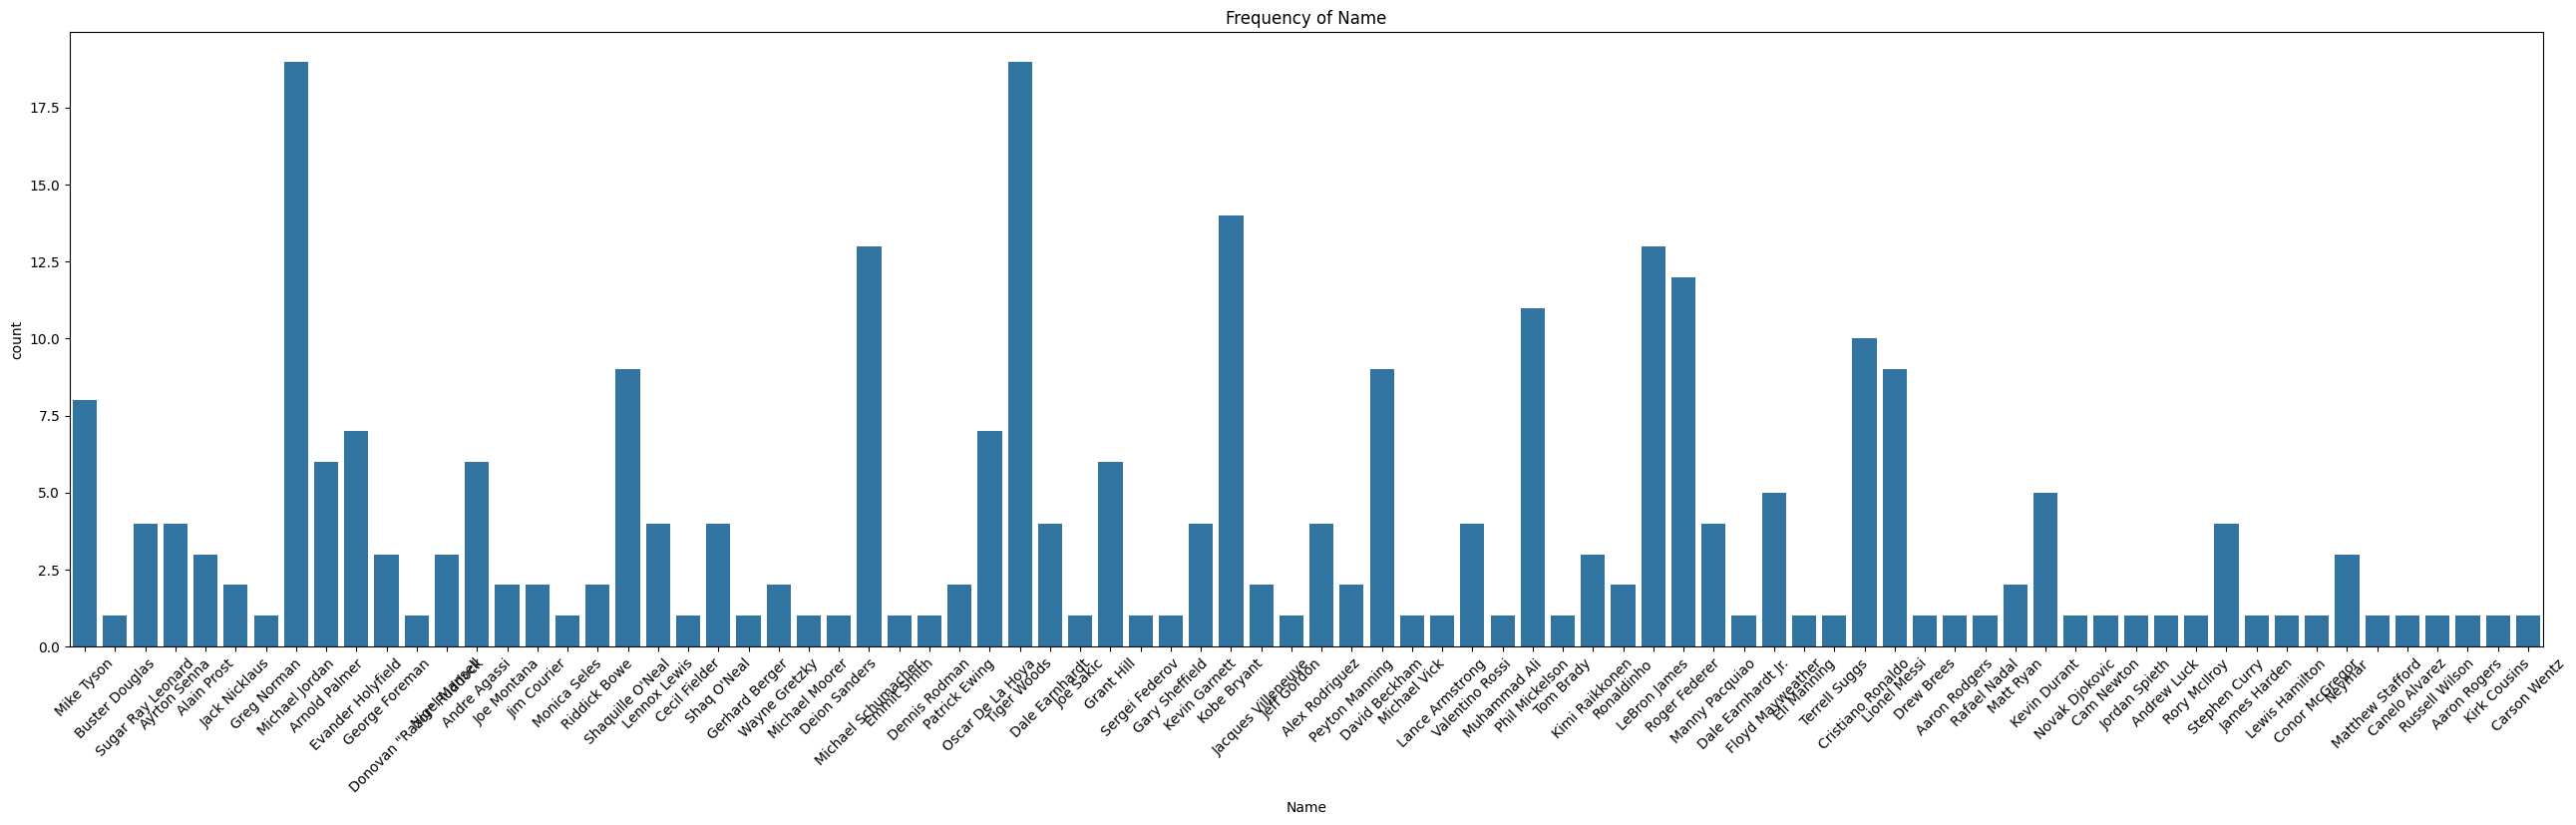

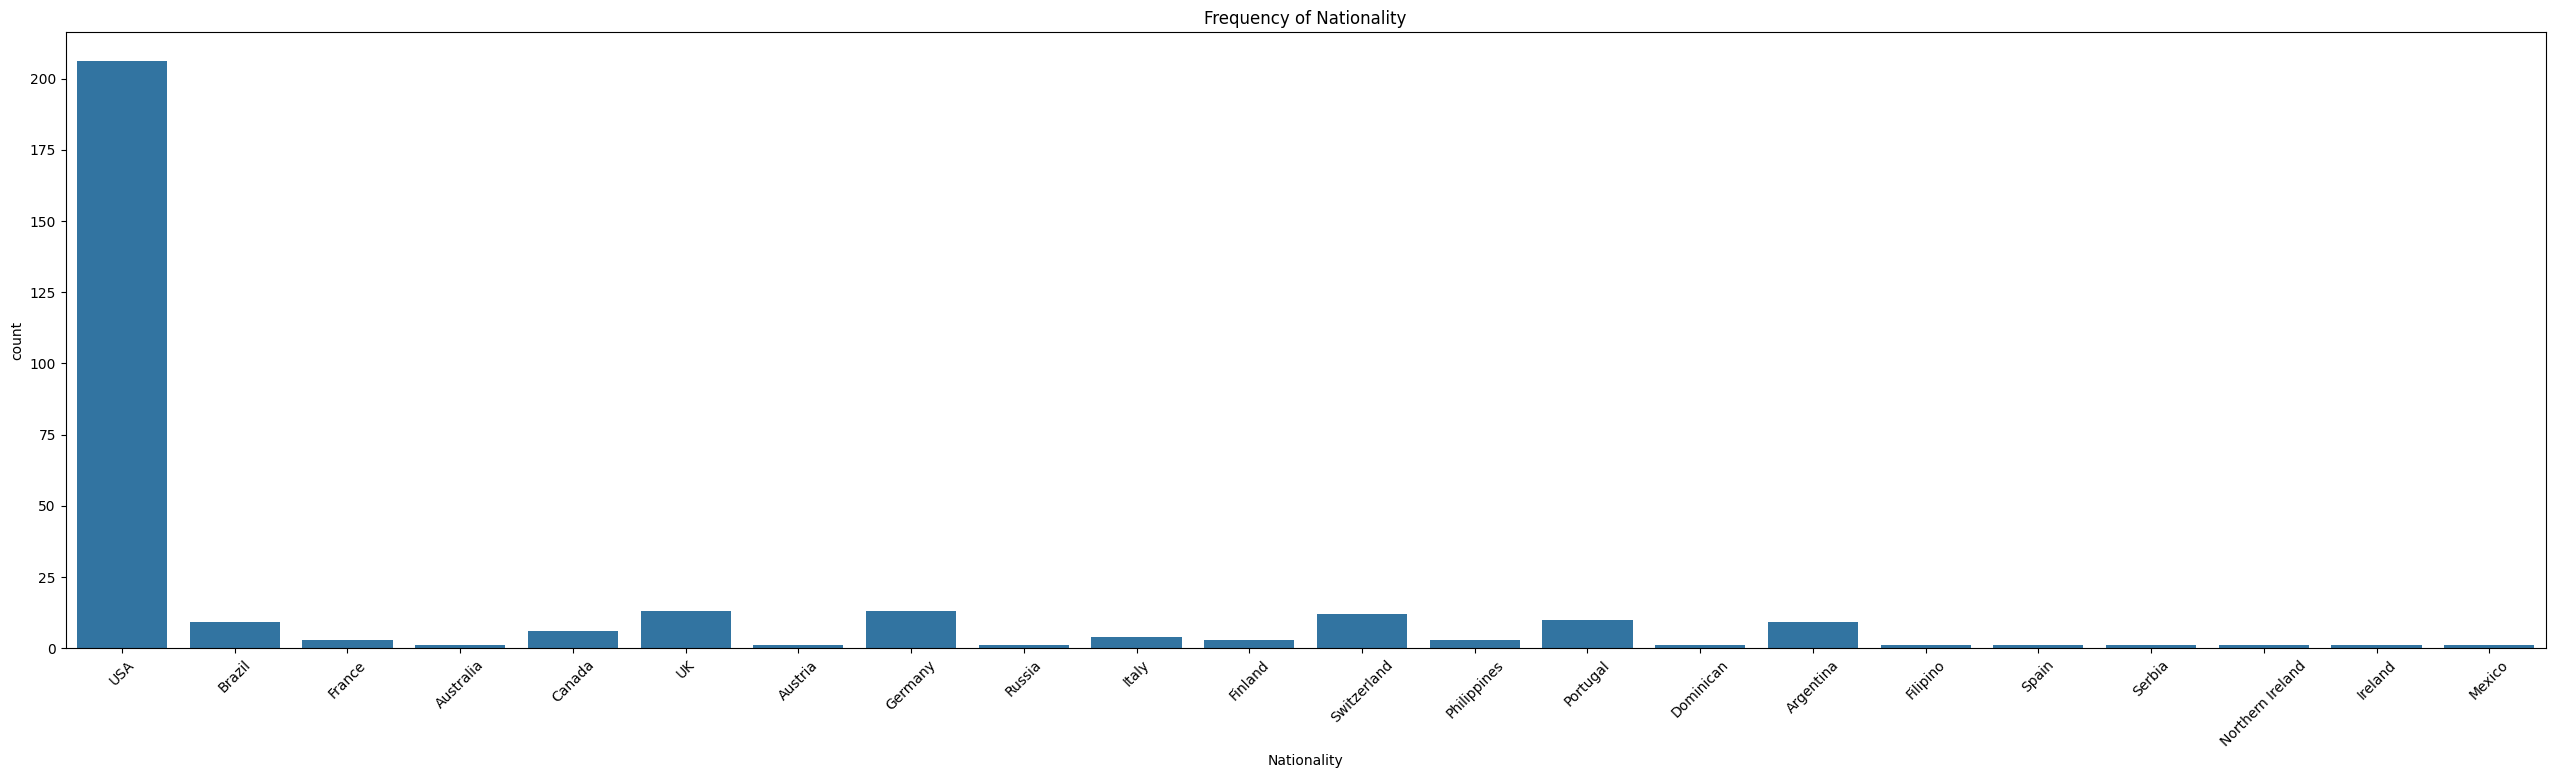

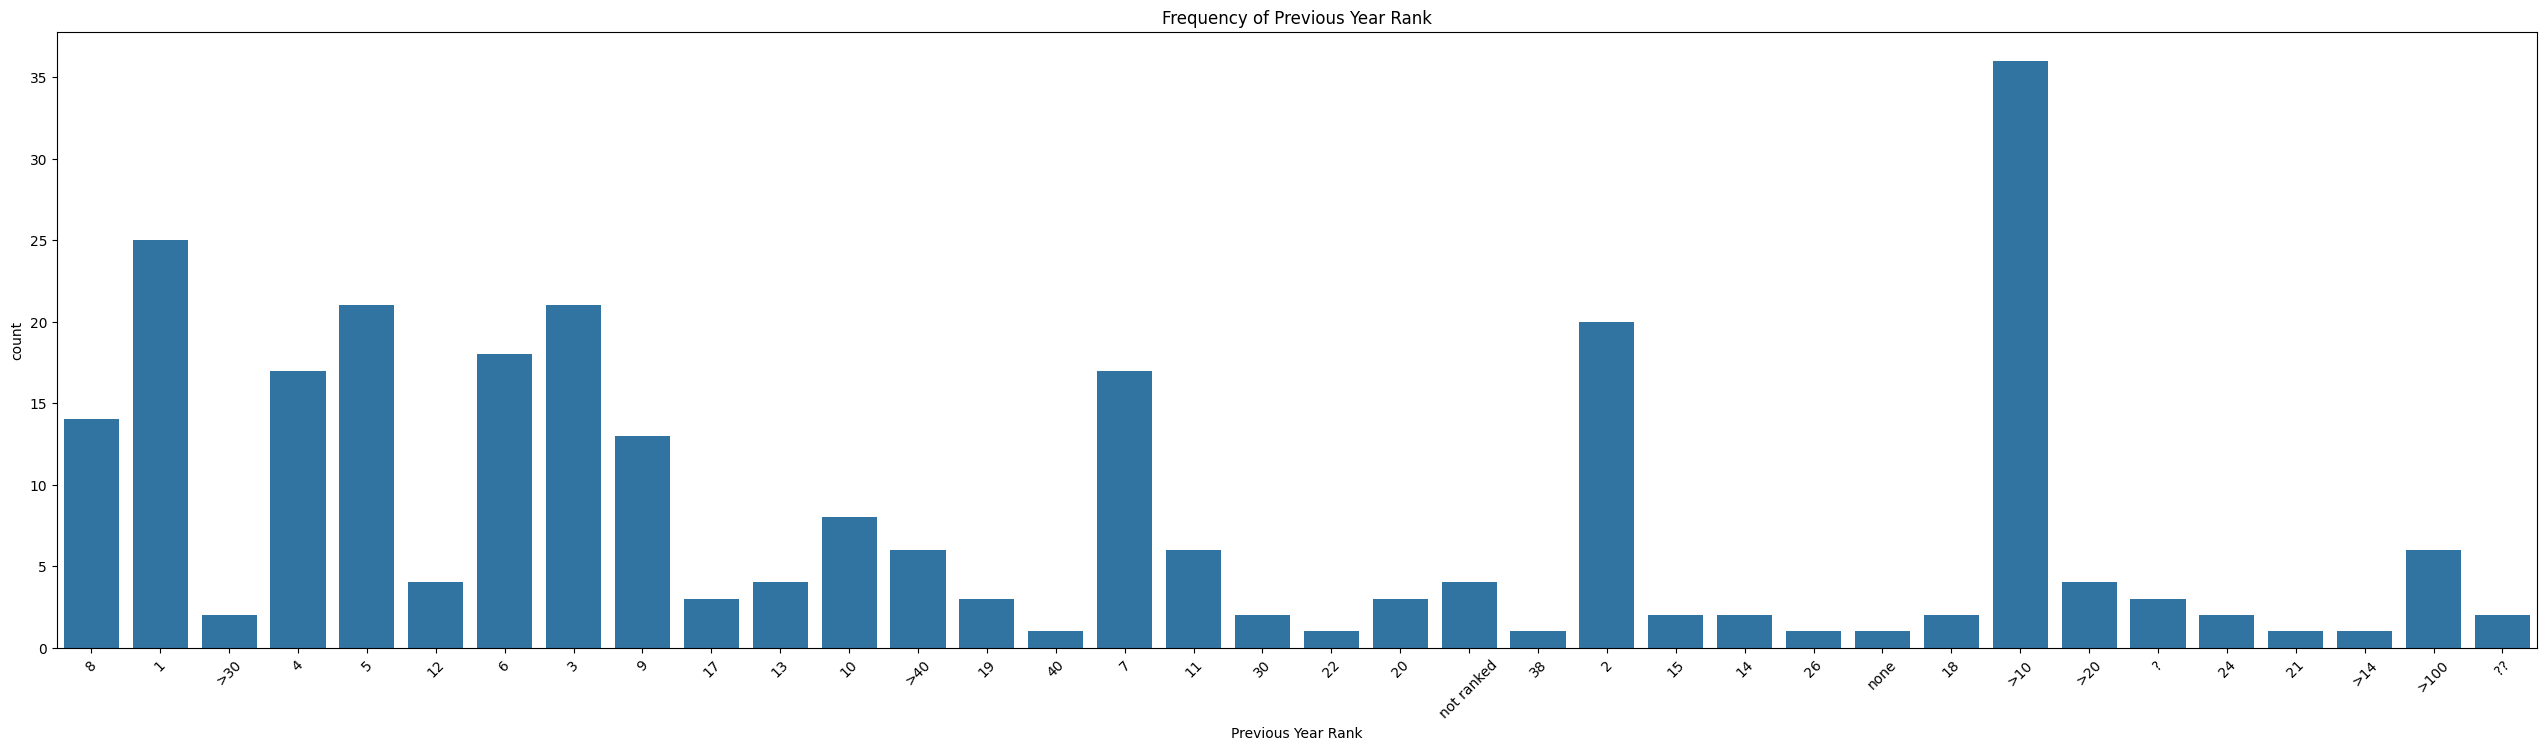

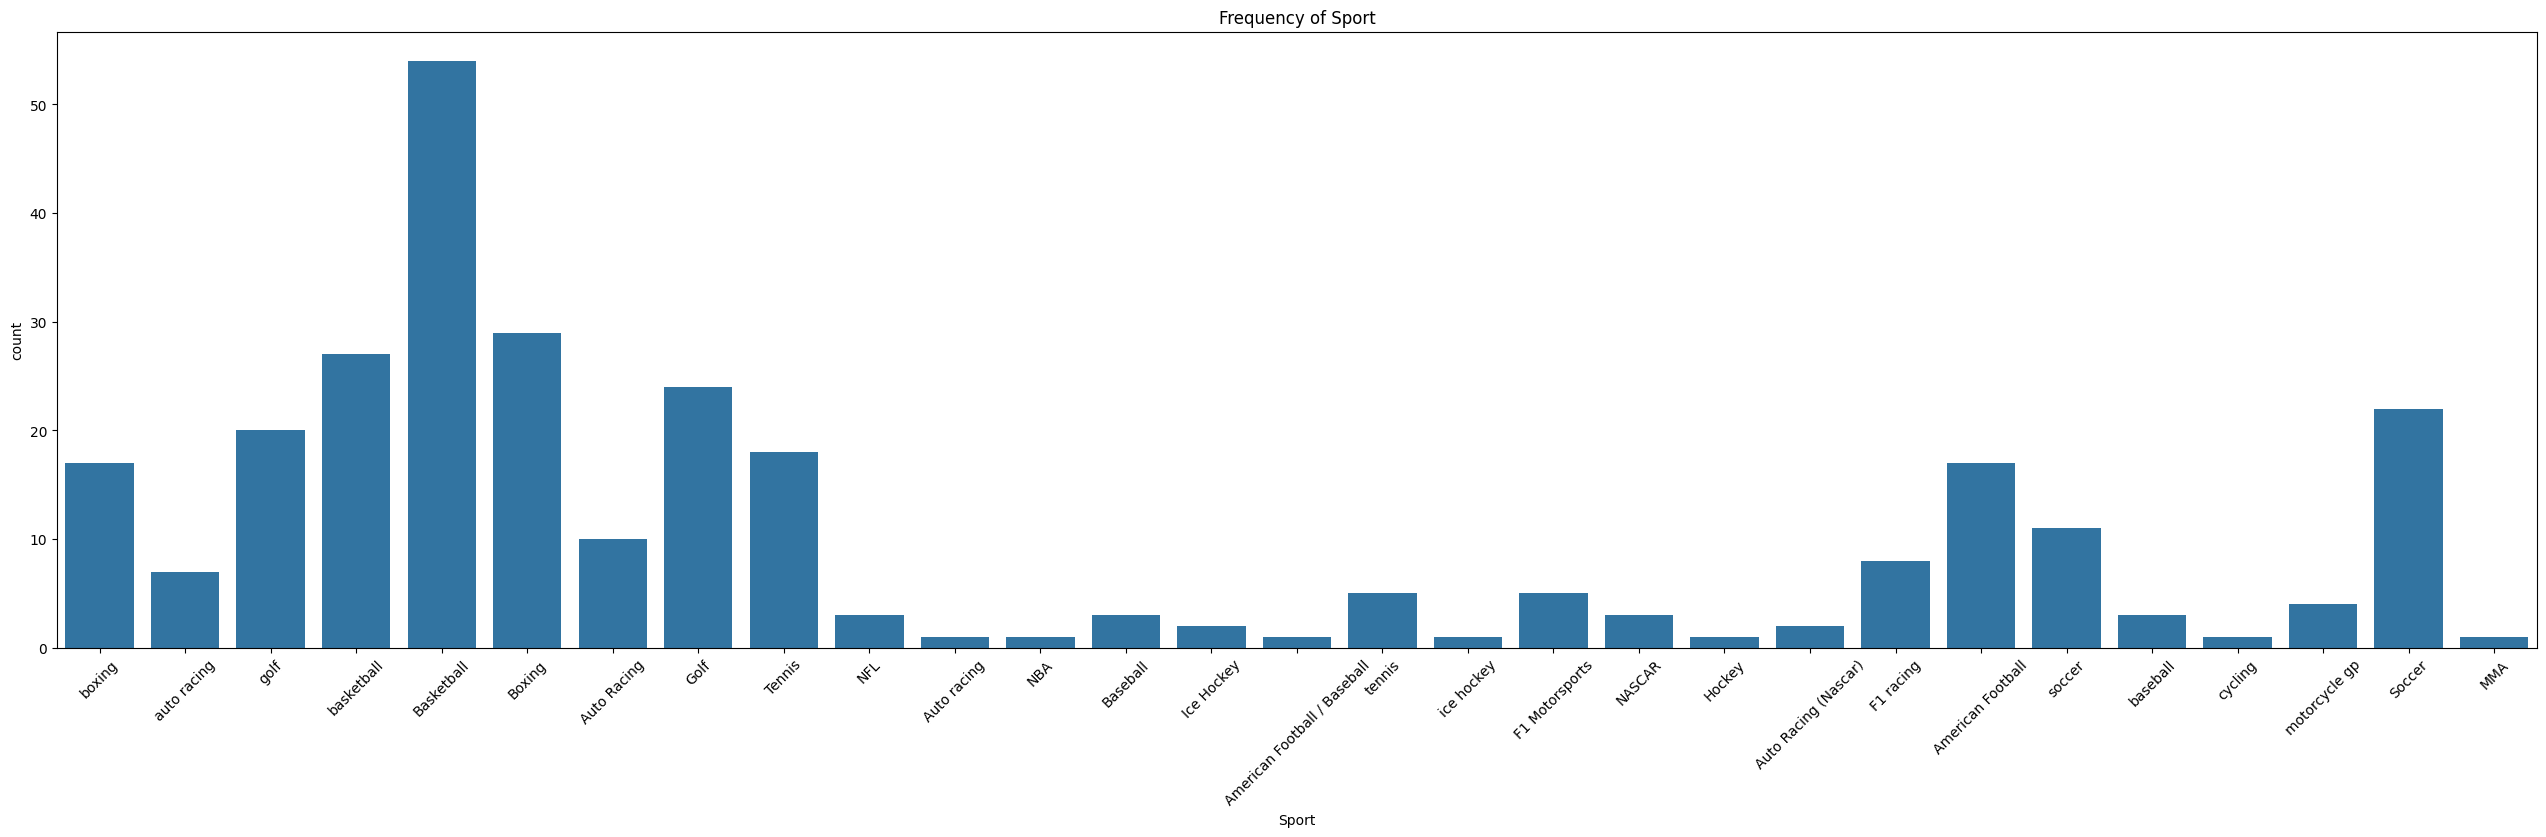

In [29]:
for col in categorical_cols:

    plt.figure(figsize=(32,8))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f"Frequency of {col}")
    plt.show()

## Relaciones entre variables numéricas

Analizamos correlaciones entre variables cuantitativas.

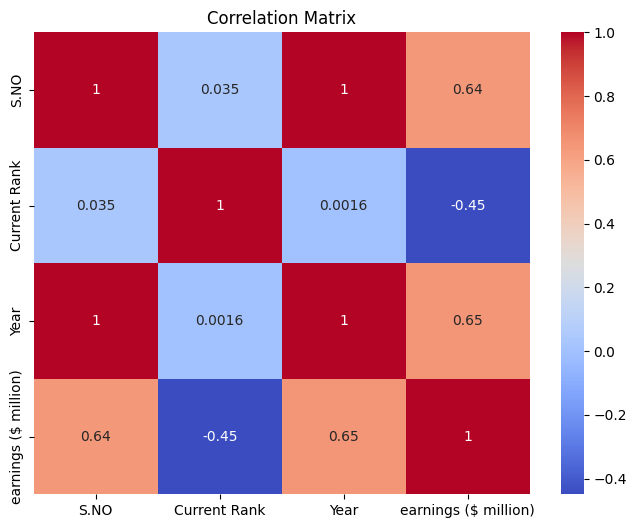

In [30]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Conclusiones

El dataset contiene variables:

### Numéricas
- S.NO
- Current Rank
- Previous Year Rank
- Year
- earnings ($ million)

Estadísticos adecuados:

- media
- mediana
- desviación estándar
- rango
- cuartiles

### Categóricas
- Name
- Nationality
- Sport

Estadísticos adecuados:

- moda
- frecuencia absoluta
- frecuencia relativa
- cardinalidad

### Observaciones

- `Previous Year Rank` contiene valores faltantes.
- `earnings` presenta distribución posiblemente sesgada.
- `Year` permite análisis temporal.

Este análisis permite preparar el dataset para **modelos de machine learning o análisis exploratorio más profundo**.